# Solution one : Feature selection + Train + log to MLFlow

# 0.Library

In [19]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.pipeline import Pipeline

# MLFlow
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [ ]:
# Read dataframe
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "2.cleaned_features_13_patients.csv"
 
df = pd.read_csv(df_path)

df.head()

,Age,Help_Rating_out_of_5,MoCA_Score,Tutorial_total_reading_time,Tutorial_intensity_reading_time,Tutorial_total_count_hover,Tutorial_total_duration_hover,Tutorial_mean_duration_hover,Tutorial_max_duration_hover,Tutorial_total_count_press,...,Memory_Yaw_std,Memory_Pitch_std,Memory_Roll_std,Memory_Yaw_range,Memory_Roll_range,Memory_dominant_hand_mean_speed,Memory_not_dominant_hand_mean_speed,Memory_dominant_hand_z_range,Memory_not_dominant_hand_y_range,Gender_Male
0,73.0,4,28.0,45.03,0.92,32,20.64,1.03,2.29,8,...,26.23,161.72,177.36,99.05,360.00,0.16,0.03,0.82,0.80,0
1,82.0,1,26.0,338.75,0.99,688,145.79,2.11,20.01,9,...,23.27,161.90,162.61,109.38,359.99,0.06,0.01,0.98,0.75,1
2,62.0,1,27.0,152.90,0.97,61,54.33,1.81,11.62,8,...,30.07,170.64,169.17,248.93,359.98,0.12,0.02,1.05,0.58,1
3,78.0,2,27.0,181.69,0.98,26,91.62,2.78,23.45,9,...,31.96,136.51,170.83,174.64,359.98,0.12,0.02,0.82,0.42,0
4,71.0,2,26.0,190.51,0.98,109,102.68,2.57,21.86,8,...,27.48,169.32,125.66,146.78,359.99,0.11,0.03,0.82,0.64,0


# 2. Data visualization of 13 real patients (7 of them where removed)

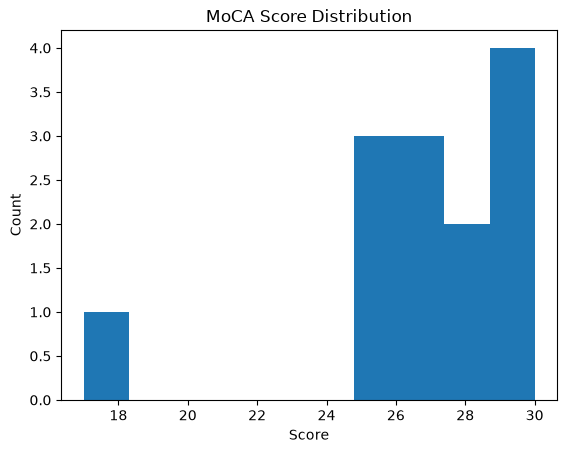

In [21]:
plt.hist(df['MoCA_Score'], bins=10)
plt.title("MoCA Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

Fill MoCA by 26(int) for all 20 young patient...
Fill Nan by median for real patient...
No more Nan values in MoCA.
MoCA column is dropped and Target column is created successfully.


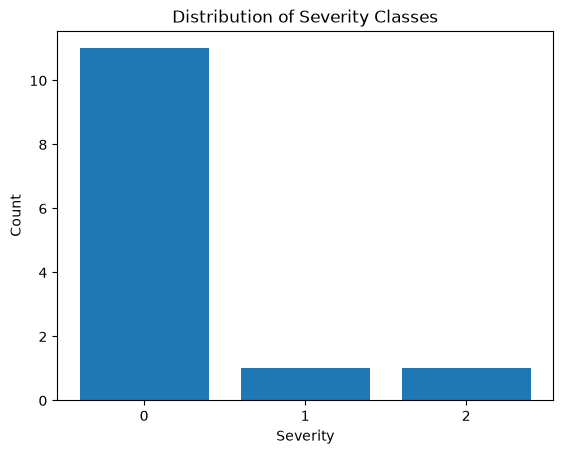

In [22]:
df_classification = dp.create_target_column(df)

counts = df_classification["Target"].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Severity")
plt.ylabel("Count")
plt.title("Distribution of Severity Classes")
plt.show()

# 3. Data Splitting

In [23]:
y = df['MoCA_Score']
df = df.drop(columns=['MoCA_Score'])
X = df

# 4. Train and Test on 13 patients

In [24]:
# experiment list
experiments_list = cd.all_experiments_sol_1
loo = LeaveOneOut()

for exp_name, models_list, k_value in experiments_list:
    
    print(f"================ Experiment: {exp_name} with k={k_value} ================")
    mlflow.set_experiment(f"MoCA_Regression_feaute_selection_{exp_name}_{k_value}")

    for model_name, model_fn in models_list:
        print(f"======== Run: {exp_name}_{model_name} ========")
        with mlflow.start_run(run_name=f"{exp_name}_{model_name}"):

            pipe = mu.make_model_pipeline(
                mu.make_feature_pipeline(exp_name, k_value),
                model_fn()
            )

            scores = cross_validate(
                pipe,
                X,
                y,
                cv=loo,
                scoring={
                    "mae": "neg_mean_absolute_error",
                    "mse": "neg_mean_squared_error",
                    "rmse": "neg_root_mean_squared_error"
                },
                return_train_score=True
            )

            # compute metrics of test set
            mae_test  = -scores["test_mae"].mean()
            mse_test  = -scores["test_mse"].mean()
            rmse_test = -scores["test_rmse"].mean()

            # compute metrics of train set
            mae_train  = -scores["train_mae"].mean()
            mse_train  = -scores["train_mse"].mean()
            rmse_train = -scores["train_rmse"].mean()

            # compute gap (overfitting)
            gap = mse_test - mse_train

            # print
            print(f"Model: {model_name}")
            print(f"MSE of test: {mse_test:.3f}")
            print(f"MSE of train: {mse_train:.3f}")
            print(f"Gap: {gap:.3f}")

            # MLflow logging
            mlflow.log_param("experiment", exp_name)
            mlflow.log_param("model", model_name)

            mlflow.log_metric("mae_test", mae_test)
            mlflow.log_metric("mse_test", mse_test)
            mlflow.log_metric("rmse_test", rmse_test)

            mlflow.log_metric("mae_train", mae_train)
            mlflow.log_metric("mse_train", mse_train)
            mlflow.log_metric("rmse_train", rmse_train)

            mlflow.log_metric("gap", gap)

            # log model
            mlflow.sklearn.log_model(pipe, name="model", skops_trusted_types=["xgboost.sklearn.XGBRegressor", "sklearn.feature_selection._univariate_selection.f_regression"])


================ Experiment: all_features with k=0 ================
======== Run: all_features_LinearRegression ========
Model: LinearRegression
MSE of test: 10.036
MSE of train: 0.000
Gap: 10.036
======== Run: all_features_Ridge ========
Model: Ridge
MSE of test: 10.020
MSE of train: 0.000
Gap: 10.019
======== Run: all_features_RandomForest ========
Model: RandomForest
MSE of test: 10.366
MSE of train: 1.000
Gap: 9.367
======== Run: all_features_XGBRegressor ========
Model: XGBRegressor
MSE of test: 25.601
MSE of train: 0.000
Gap: 25.601
======== Run: all_features_SVR ========
Model: SVR
MSE of test: 11.016
MSE of train: 7.203
Gap: 3.813
======== Run: all_features_Lasso ========
Model: Lasso
MSE of test: 12.317
MSE of train: 1.976
Gap: 10.341
================ Experiment: SelectKBest with k=50 ================
======== Run: SelectKBest_LinearRegression ========
Model: LinearRegression
MSE of test: 10.762
MSE of train: 0.000
Gap: 10.762
======== Run: SelectKBest_Ridge ========
Model: Ri